In [4]:
import copy
from music21 import stream, note, chord, duration

def _is_note_like(e):
    return isinstance(e, (note.Note, chord.Chord, note.Unpitched))

def _container_of(e):
    for cls in (stream.Voice, stream.Measure, stream.Part, stream.Stream):
        ctx = e.getContextByClass(cls)
        if ctx is not None:
            return ctx
    return e.activeSite

def _next_main_in_container(cont, anchor, include_same_offset=True):
    anchor_off = anchor.getOffsetBySite(cont)
    seen = False
    for e in cont.recurse().notesAndRests:
        off = e.getOffsetBySite(cont)
        if e is anchor:
            seen = True
            continue
        if not seen:
            continue
        cond = off >= anchor_off if include_same_offset else off > anchor_off
        if cond and (_is_note_like(e) or e.isRest):
            return e
    return None

def _shorten_duration(obj, qL):
    if hasattr(obj, 'duration') and not getattr(obj, 'isRest', False):
        obj.duration.quarterLength = max(0.0, obj.duration.quarterLength - qL)

def grace_dual_representation(
    s,
    per_grace_qL=0.25,
    move_following=True,
    steal_from_next=True,
    tie_safe=False,
    tag_editorial=True
):
    """
    为每个 Grace 保留原样用于可视化；再生成一颗“隐藏的普通音”供机器使用。
    通过 groups 打标签：'machineFromGrace'。
    """
    graces = [n for n in s.recurse().notes if getattr(n.duration, 'isGrace', False)]

    for g in graces:
        cont = _container_of(g)
        if cont is None:
            continue

        next_main = _next_main_in_container(cont, g, include_same_offset=True)
        cur_off = g.getOffsetBySite(cont)
        next_off = next_main.getOffsetBySite(cont) if next_main is not None else cur_off

        # 隐藏“普通音”的起点：紧贴主音之前
        start_off = max(0.0, next_off - per_grace_qL) if next_main is not None else cur_off

        # 用 deepcopy 复制
        mach = copy.deepcopy(g)
        mach.duration = duration.Duration(per_grace_qL)

        # 用 groups 打标签（避免 Editorial.misc 兼容问题）
        if tag_editorial:
            try:
                mach.addGroup('machineFromGrace')
            except Exception:
                # 极少数情况下没有 addGroup；可忽略
                pass

        # 在乐谱上隐藏，但在流里仍存在
        mach.style.hideObjectOnPrint = True

        # 插入
        cont.insert(start_off, mach)

        # 机器时间下处理后续主音
        if next_main is not None:
            if move_following:
                cont.remove(next_main, recurse=False)
                cont.insert(start_off + per_grace_qL, next_main)

            if steal_from_next and not next_main.isRest:
                if tie_safe and getattr(next_main, 'tie', None):
                    pass
                else:
                    _shorten_duration(next_main, per_grace_qL)



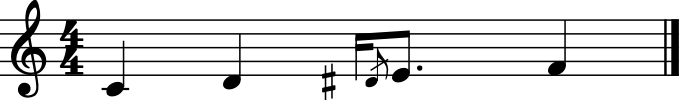

{0.0} <music21.stream.Measure 1 offset=0.0>
    {0.0} <music21.clef.TrebleClef>
    {0.0} <music21.meter.TimeSignature 4/4>
    {0.0} <music21.note.Note C>
    {1.0} <music21.note.Note D>
    {1.75} <music21.note.Note D#>
    {2.0} <music21.note.Note D#>
    {2.0} <music21.note.Note E>
    {3.0} <music21.note.Note F>
    {4.0} <music21.bar.Barline type=final>


In [5]:
from music21 import converter, note, duration

s = converter.parse('tinyNotation: 4/4 c4 d4 e4 f4')

m1 = s.measure(1)  # tinyNotation 返回的是 Part
g = note.Note('D#4')
g.duration = duration.GraceDuration()
m1.insert(2.0, g)  # e4 也在 2.0

grace_dual_representation(
    s,
    per_grace_qL=0.25,
    move_following=True,
    steal_from_next=True
)
s.show()
s.show('text')



In [1]:
from music21 import stream, note, chord, duration
c = chord.Chord(['G2', 'F#4', 'B4'])
c.seventh

<music21.pitch.Pitch F#4>